# 3DBreastNet - 128x128x128 Voxel Reconstruction

## 1. Install Dependencies

In [1]:
!uv pip install torch torchvision tifffile opencv-python numpy scipy scikit-image matplotlib tqdm pandas

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv


Checked 10 packages in 56ms


In [2]:
# tqdm.notebook is provided by tqdm; ipywidgets enables the notebook progress UI.
!uv pip install tqdm ipywidgets

Using Python 3.11.9 environment at: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv
Checked 2 packages in 57ms


## 2. Model Definitions

In [2]:
"""3DBreastNet — Model definitions (128³ voxel grid)."""
import math, torch, torch.nn as nn, torch.nn.functional as F

# ── Building blocks ──────────────────────────────────────────
class DoubleConv2D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity(),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)

class DoubleConv3D(nn.Module):
    def __init__(self, inc, outc, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True),
            nn.Dropout3d(drop) if drop > 0 else nn.Identity(),
            nn.Conv3d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm3d(outc), nn.ReLU(True))
    def forward(self, x): return self.block(x)

def _init(m):
    if isinstance(m, (nn.Conv2d, nn.Conv3d, nn.ConvTranspose2d, nn.ConvTranspose3d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm3d)):
        nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None: nn.init.constant_(m.bias, 0)

# ── U-Net (for mask generation, frozen) ──────────────────────
class DoubleConv(nn.Module):
    def __init__(self, inc, outc, drop=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(inc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Conv2d(outc, outc, 3, padding=1, bias=False),
            nn.BatchNorm2d(outc), nn.ReLU(True),
            nn.Dropout2d(drop) if drop > 0 else nn.Identity())
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_c=1, out_c=1, b=64, drop=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_c, b, 0.0)
        self.enc2 = DoubleConv(b, b*2, 0.0)
        self.enc3 = DoubleConv(b*2, b*4, 0.1)
        self.enc4 = DoubleConv(b*4, b*8, 0.1)
        self.bottleneck = DoubleConv(b*8, b*16, drop)
        self.up4 = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8, 0.1)
        self.up3 = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.dec3 = DoubleConv(b*8, b*4, 0.1)
        self.up2 = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.dec2 = DoubleConv(b*4, b*2, 0.0)
        self.up1 = nn.ConvTranspose2d(b*2, b, 2, stride=2)
        self.dec1 = DoubleConv(b*2, b, 0.0)
        self.out = nn.Conv2d(b, out_c, 1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.dec4(torch.cat([self.up4(b),e4],1))
        d3=self.dec3(torch.cat([self.up3(d4),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1))
        d1=self.dec1(torch.cat([self.up1(d2),e1],1))
        return self.out(d1)

# ── Encoder 2D  (5×128×128 → 1000-d latent) ─────────────────
class Encoder2D(nn.Module):
    def __init__(self, drop=0.25):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv2D(5, 32, 0)
        self.enc2 = DoubleConv2D(32, 64, 0)
        self.enc3 = DoubleConv2D(64, 128, drop)
        self.enc4 = DoubleConv2D(128, 256, drop)
        self.enc5 = DoubleConv2D(256, 512, drop)
        self.enc6 = DoubleConv2D(512, 512, drop)
        self.fc = nn.Sequential(nn.Dropout(drop), nn.Linear(512*2*2, 1000))
        self.apply(_init)
    def forward(self, x):
        for enc in [self.enc1, self.enc2, self.enc3, self.enc4, self.enc5, self.enc6]:
            x = enc(x); x = self.pool(x)
        return self.fc(x.view(x.size(0), -1))

# ── Decoder 3D  (1000-d → 1×128×128×128) with grad-checkpoint
class Decoder3D(nn.Module):
    def __init__(self, drop=0.25):
        super().__init__()
        self.fc = nn.Linear(1000, 512*2*2*2)
        self.up1=nn.ConvTranspose3d(512,256,2,stride=2); self.d1=DoubleConv3D(256,256,drop)
        self.up2=nn.ConvTranspose3d(256,128,2,stride=2); self.d2=DoubleConv3D(128,128,drop)
        self.up3=nn.ConvTranspose3d(128,64,2,stride=2);  self.d3=DoubleConv3D(64,64,drop)
        self.up4=nn.ConvTranspose3d(64,32,2,stride=2);   self.d4=DoubleConv3D(32,32,0)
        self.up5=nn.ConvTranspose3d(32,16,2,stride=2);   self.d5=DoubleConv3D(16,16,0)
        self.up6=nn.ConvTranspose3d(16,8,2,stride=2);    self.d6=DoubleConv3D(8,8,0)
        self.out = nn.Sequential(nn.Conv3d(8,1,1), nn.Sigmoid())
        self.apply(_init)
        nn.init.constant_(self.out[0].bias, -4.0)   # start near-empty

    def _s4(self, x): return self.d4(self.up4(x))
    def _s5(self, x): return self.d5(self.up5(x))
    def _s6(self, x): return self.d6(self.up6(x))

    def forward(self, x):
        x = self.fc(x).view(x.size(0), 512, 2, 2, 2)
        x = self.d1(self.up1(x))
        x = self.d2(self.up2(x))
        x = self.d3(self.up3(x))
        if x.requires_grad:
            x = torch.utils.checkpoint.checkpoint(self._s4, x, use_reentrant=False)
            x = torch.utils.checkpoint.checkpoint(self._s5, x, use_reentrant=False)
            x = torch.utils.checkpoint.checkpoint(self._s6, x, use_reentrant=False)
        else:
            x = self._s4(x); x = self._s5(x); x = self._s6(x)
        return self.out(x)

# ── Differentiable projection (Eq. 1-3 from paper) ──────────
# Runs in pure float32 (isolated from autocast in train.py)
def render_projection(volume, theta_deg):
    B,C,D,H,W = volume.shape; dev = volume.device
    if not isinstance(theta_deg, torch.Tensor):
        theta_deg = torch.full((B,), float(theta_deg), device=dev, dtype=torch.float32)
    theta_deg = theta_deg.float()
    rad = theta_deg * math.pi / 180.0
    c, s = torch.cos(rad), torch.sin(rad)
    z, o = torch.zeros_like(rad), torch.ones_like(rad)
    mat = torch.stack([torch.stack([c,z,s,z],-1),
                       torch.stack([z,o,z,z],-1),
                       torch.stack([-s,z,c,z],-1)], -2)
    grid = F.affine_grid(mat, volume.shape, align_corners=False)
    Vr = F.grid_sample(volume, grid, mode='bilinear', padding_mode='zeros', align_corners=False)
    return 1.0 - torch.exp(-Vr.squeeze(1).sum(dim=1, keepdim=True))

# ── Dice loss (Eq. 7) — float32-safe ────────────────────────
def dice_loss(pred, target, eps=1e-6):
    p, t = pred.float(), target.float()
    num = 2*(p*t).sum()
    den = p.pow(2).sum() + t.pow(2).sum() + eps
    return 1 - num/den

VIEW_WINDOWS = [(-90.,-67.5),(-67.5,-22.5),(-22.5,22.5),(22.5,67.5),(67.5,90.)]


## 3. Training

In [10]:
"""3DBreastNet — Training script for 128³ voxel reconstruction.
Usage:  python train.py
"""
import os, sys, time, random, json, math
import numpy as np, cv2, tifffile, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.ndimage

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
CFG = {
    "epochs":       400,
    "batch_size":   2,
    "lr":           1e-4,
    "betas":        (0.5, 0.9),
    "n_per_view":   2,
    "seed":         42,
    "patience":     50,
    "ckpt_dir":     "checkpoints_3d",
    "tiff_base":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient",
    "unet_ckpt":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth",
}

# ════════════════════════════════════════════════════════════════
# DATA
# ════════════════════════════════════════════════════════════════
@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]

def get_view_key(filename):
    n = filename.lower()
    if "right later" in n: return "RL"
    if "right obli"  in n: return "RO"
    if "frontal" in n or "anterior" in n: return "F"
    if "left obliq"  in n: return "LO"
    if "left later"  in n: return "LL"
    return None

def build_patient_groups(tiff_base):
    tb = Path(tiff_base)
    pd_ = {}
    for tp in tb.rglob("*.tiff"):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {"views": {}}
        pd_[key]["views"][vk] = tp
    groups, skip, nb_, nm = [], 0, 0, 0
    for (pid, lab), d in pd_.items():
        if len(d["views"]) == 5:
            groups.append(PatientGroup(pid, lab, d["views"]))
            nb_ += lab.lower() == "benign"; nm += lab.lower() != "benign"
        else:
            print(f"  Skip {pid} ({lab}): {len(d['views'])}/5 views"); skip += 1
    groups.sort(key=lambda g: g.patient_id)
    print(f"Patients: {len(pd_)} | Complete: {len(groups)} | "
          f"Skipped: {skip} | B={nb_} M={nm}")
    return groups

class PatientDataset(Dataset):
    def __init__(self, groups, unet, device, img_sz=256):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz = img_sz
        self.views = ["RL","RO","F","LO","LL"]
    def __len__(self): return len(self.groups)
    def __getitem__(self, idx):
        g = self.groups[idx]; thermals, masks = [], []
        for v in self.views:
            raw = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)
            # Always use U-Net for consistent segmentation
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5).astype(np.float32)
            masks.append(cv2.resize(m, (128,128), interpolation=cv2.INTER_NEAREST))
        return {
            "masks_5ch": torch.tensor(np.stack(masks), dtype=torch.float32),
            "thermals_5ch": torch.tensor(np.stack(thermals), dtype=torch.float32),
            "patient_id": g.patient_id, "label": g.label,
        }

# ════════════════════════════════════════════════════════════════
# METRICS
# ════════════════════════════════════════════════════════════════
def hd95(p, t):
    if p.sum()==0 or t.sum()==0: return 128.0
    pe = p ^ scipy.ndimage.binary_erosion(p)
    te = t ^ scipy.ndimage.binary_erosion(t)
    dtp = scipy.ndimage.distance_transform_edt(~pe)
    dtt = scipy.ndimage.distance_transform_edt(~te)
    d1 = np.percentile(dtt[pe], 95) if pe.sum()>0 else 128.0
    d2 = np.percentile(dtp[te], 95) if te.sum()>0 else 128.0
    return max(d1, d2)

# ════════════════════════════════════════════════════════════════
# TRAIN
# ════════════════════════════════════════════════════════════════
def train(cfg):
    torch.manual_seed(cfg["seed"]); np.random.seed(cfg["seed"])
    torch.cuda.manual_seed_all(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # U-Net (frozen)
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(cfg["unet_ckpt"], map_location=device))
    unet.eval()
    for p in unet.parameters(): p.requires_grad = False

    # Data
    groups = build_patient_groups(cfg["tiff_base"])
    rng = random.Random(cfg["seed"])
    ben = [g for g in groups if g.label.lower()=="benign"]
    mal = [g for g in groups if g.label.lower()!="benign"]
    rng.shuffle(ben); rng.shuffle(mal)
    s = 0.78
    trn = ben[:int(len(ben)*s)] + mal[:int(len(mal)*s)]
    val = ben[int(len(ben)*s):] + mal[int(len(mal)*s):]
    print(f"Train: {len(trn)} | Val: {len(val)}")

    trn_dl = DataLoader(PatientDataset(trn, unet, device),
                        batch_size=cfg["batch_size"], shuffle=True, drop_last=True)
    val_dl = DataLoader(PatientDataset(val, unet, device),
                        batch_size=cfg["batch_size"], shuffle=False)

    # Models
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    opt = torch.optim.Adam(list(enc.parameters())+list(dec.parameters()),
                           lr=cfg["lr"], betas=cfg["betas"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=30, min_lr=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    Path(cfg["ckpt_dir"]).mkdir(parents=True, exist_ok=True)

    best_dice, no_imp = 0.0, 0
    hist = {"epoch":[], "train_loss":[], "val_loss":[], "val_dice":[], "val_hd":[]}
    val_angles = [-90., -45., 0., 45., 90.]

    for epoch in range(1, cfg["epochs"]+1):
        t0 = time.time()
        # ── train ──
        enc.train(); dec.train()
        ep_loss = 0.0
        for batch in tqdm(trn_dl, desc=f"E{epoch:03d} train", leave=False):
            m5 = batch["masks_5ch"].to(device)
            B = m5.size(0)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                vol = dec(enc(m5))
            
            vol = vol.float()
            loss = torch.tensor(0.0, device=device)
            for i in range(5):
                lo, hi = VIEW_WINDOWS[i]
                for _ in range(cfg["n_per_view"]):
                    th = torch.rand(B, device=device)*(hi-lo)+lo
                    loss = loss + dice_loss(render_projection(vol, th),
                                            m5[:, i:i+1])
            loss = loss / (5*cfg["n_per_view"])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            # NaN guard: skip step if loss exploded
            if torch.isfinite(loss):
                torch.nn.utils.clip_grad_norm_(
                    list(enc.parameters())+list(dec.parameters()), 1.0)
                scaler.step(opt)
            else:
                print(f"  ⚠ NaN loss in epoch {epoch}, skipping batch")
            scaler.update()
            opt.zero_grad(set_to_none=True)
            ep_loss += loss.item() if torch.isfinite(loss) else 0.0
        ep_loss /= max(len(trn_dl), 1)

        # ── val ──
        enc.eval(); dec.eval()
        vl, vd, vh, cnt = 0., 0., 0., 0
        with torch.no_grad():
            for batch in tqdm(val_dl, desc=f"E{epoch:03d} val", leave=False):
                m5 = batch["masks_5ch"].to(device); B = m5.size(0)
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                    vol = dec(enc(m5))
                
                vol = vol.float()
                for i in range(5):
                    th = torch.full((B,), val_angles[i], device=device)
                    proj = render_projection(vol, th)
                    dl = dice_loss(proj, m5[:, i:i+1])
                    vl += dl.item(); vd += (1-dl).item()
                    pb = (proj>0.5).cpu().numpy()
                    mb = (m5[:, i:i+1]>0.5).cpu().numpy()
                    for b in range(B): vh += hd95(pb[b,0], mb[b,0]); cnt += 1
        vl /= max(len(val_dl)*5,1); vd /= max(len(val_dl)*5,1)
        vh /= max(cnt,1)
        elapsed = time.time()-t0

        hist["epoch"].append(epoch); hist["train_loss"].append(ep_loss)
        hist["val_loss"].append(vl); hist["val_dice"].append(vd); hist["val_hd"].append(vh)
        sched.step(vd)

        lr_now = opt.param_groups[0]["lr"]
        print(f"E{epoch:03d} | loss={ep_loss:.4f} | vl={vl:.4f} vd={vd:.4f} "
              f"hd={vh:.2f} | lr={lr_now:.6f} | {elapsed:.1f}s")

        ckpt = {"epoch": epoch, "enc": enc.state_dict(), "dec": dec.state_dict(),
                "opt": opt.state_dict(), "best_dice": max(best_dice,vd),
                "cfg": cfg, "hist": hist}
        torch.save(ckpt, Path(cfg["ckpt_dir"])/"3dbreastnet_last.pth")
        if vd > best_dice:
            best_dice = vd; no_imp = 0
            torch.save(ckpt, Path(cfg["ckpt_dir"])/"3dbreastnet_best.pth")
            print(f"  ★ new best dice={best_dice:.4f}")
        else:
            no_imp += 1
            if no_imp >= cfg["patience"]:
                print(f"Early stopping @ epoch {epoch}"); break

    # ── plot ──
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(hist["epoch"], hist["train_loss"], label="train"); ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
    ax[0].set_title("Dice Loss"); ax[0].legend()
    ax[1].plot(hist["epoch"], hist["val_dice"], color="green"); ax[1].set_title("Val Dice")
    ax[2].plot(hist["epoch"], hist["val_hd"], color="red"); ax[2].set_title("Val HD95")
    for a in ax: a.set_xlabel("Epoch")
    plt.tight_layout(); plt.savefig(Path(cfg["ckpt_dir"])/"training_history.png", dpi=150)
    print(f"Plot saved. Best dice={best_dice:.4f}")

if __name__ == "__main__":
    train(CFG)

Device: cuda
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Train: 94 | Val: 28


E001 train:   0%|          | 0/47 [00:00<?, ?it/s]

E001 val:   0%|          | 0/14 [00:00<?, ?it/s]

E001 | loss=0.4616 | vl=0.3654 vd=0.6346 hd=48.56 | lr=0.000100 | 19.5s
  ★ new best dice=0.6346


E002 train:   0%|          | 0/47 [00:00<?, ?it/s]

...

E131 val:   0%|          | 0/14 [00:00<?, ?it/s]

E131 | loss=0.1279 | vl=0.1571 vd=0.8429 hd=12.67 | lr=0.000050 | 19.5s


E132 train:   0%|          | 0/47 [00:00<?, ?it/s]

E132 val:   0%|          | 0/14 [00:00<?, ?it/s]

E132 | loss=0.1268 | vl=0.1602 vd=0.8398 hd=12.88 | lr=0.000050 | 19.2s
Early stopping @ epoch 132
Plot saved. Best dice=0.8468


## View Training Metrics (Local Laptop)
Run this cell to extract the loss and dice curves from the saved checkpoint.

Loading checkpoint: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth


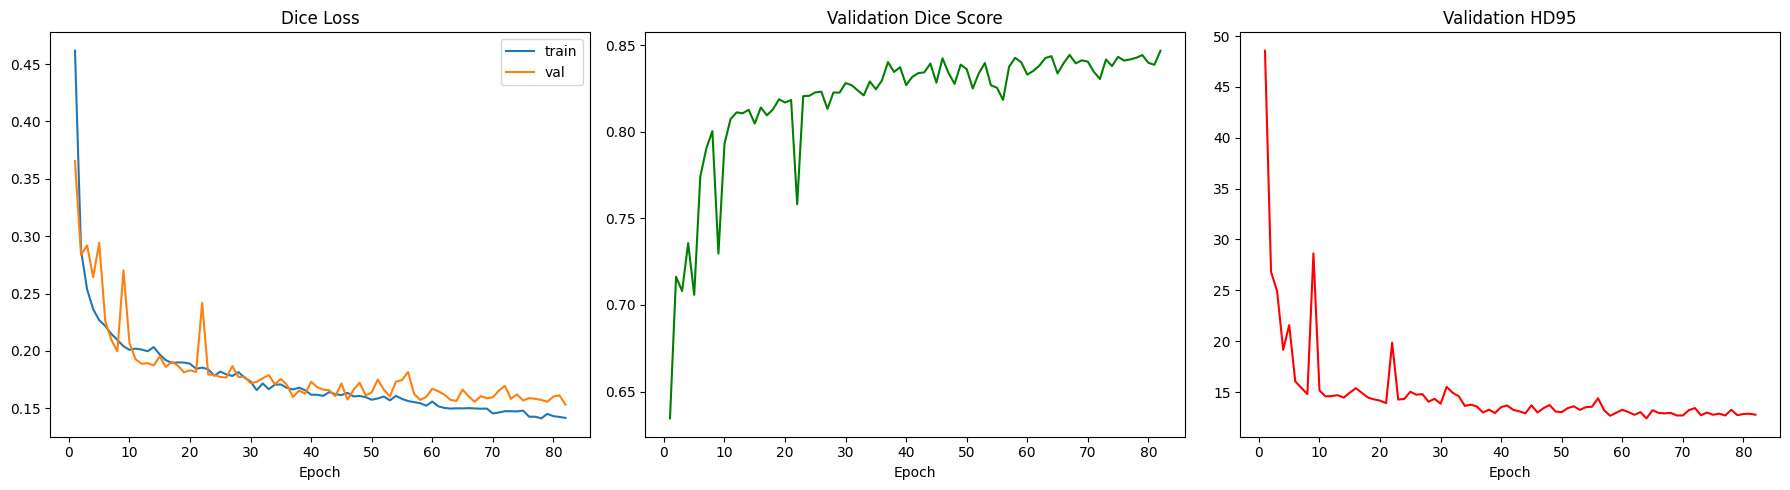

In [2]:
%matplotlib inline
# ════════════════════════════════════════════════════════════════
# PLOT TRAINING METRICS FROM SAVED CHECKPOINT (LAPTOP LOCAL)
# ════════════════════════════════════════════════════════════════
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Absolute path to your checkpoint
ckpt_path = Path(r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")

if ckpt_path.exists():
    print(f"Loading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    hist = ckpt["hist"]
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(hist["epoch"], hist["train_loss"], label="train")
    ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
    ax[0].set_title("Dice Loss"); ax[0].legend()
    
    ax[1].plot(hist["epoch"], hist["val_dice"], color="green")
    ax[1].set_title("Validation Dice Score")
    
    ax[2].plot(hist["epoch"], hist["val_hd"], color="red")
    ax[2].set_title("Validation HD95")
    
    for a in ax: a.set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()
else:
    print(f"Checkpoint not found at {ckpt_path}.")


### Fine Tuning

Fine-tuning on device: cuda
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Train: 94 | Val: 28
 Loading baseline model weights from: checkpoints_3d/3dbreastnet_best.pth
 Model loaded successfully! Initial Best Dice: 0.8468

 Starting high-fidelity voxel grid fine-tuning...


FT Epoch 001 train:   0%|          | 0/47 [00:00<?, ?it/s]

FT Epoch 001 val:   0%|          | 0/14 [00:00<?, ?it/s]

E001 | loss=0.0830 | vl=0.1525 vd=0.8475 hd=12.39 | lr=0.000020 | 20.9s
  ★ New best fine-tuned reconstruction dice=0.8475! Weights saved.


FT Epoch 002 train:   0%|          | 0/47 [00:00<?, ?it/s]

...

FT Epoch 036 val:   0%|          | 0/14 [00:00<?, ?it/s]

E036 | loss=0.0770 | vl=0.1531 vd=0.8469 hd=12.65 | lr=0.000010 | 20.2s


FT Epoch 037 train:   0%|          | 0/47 [00:00<?, ?it/s]

FT Epoch 037 val:   0%|          | 0/14 [00:00<?, ?it/s]

E037 | loss=0.0775 | vl=0.1526 vd=0.8474 hd=12.55 | lr=0.000010 | 20.0s
Early stopping fine-tuning @ epoch 37
Plots saved to 'checkpoints_3d_finetuned/fine_tuning_history.png'. Best Dice=0.8489


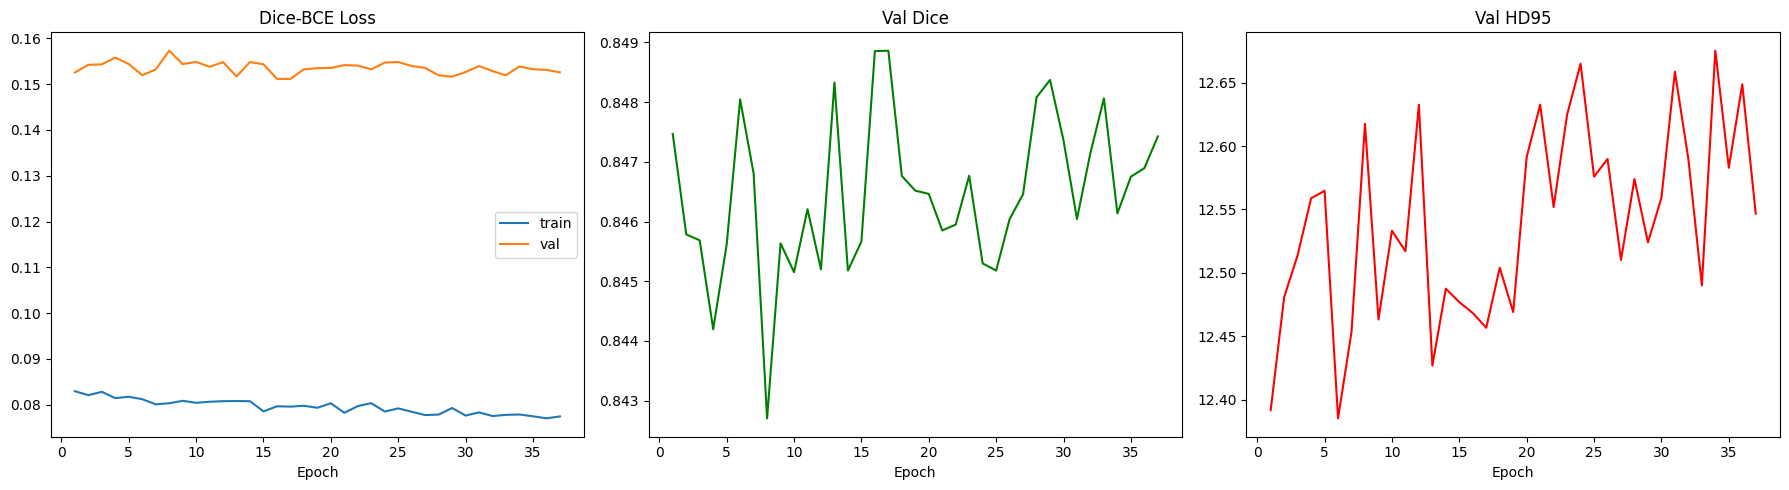

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 3DBREASTNET — VOXEL RECONSTRUCTION FINE-TUNING PIPELINE (SELF-CONTAINED & CRASH-PROOF)
# ════════════════════════════════════════════════════════════════════════════

import os, sys, time, random, json, math
import numpy as np, cv2, tifffile, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict
from tqdm.notebook import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import scipy.ndimage

# ── 1. CONFIGS ──────────────────────────────────────────────────────────────
CFG_FT = {
    "epochs":       60,                 
    "batch_size":   2,
    "lr":           2e-5,               
    "betas":        (0.5, 0.9),
    "n_per_view":   2,
    "seed":         42,
    "patience":     20,
    "ckpt_dir":     "checkpoints_3d_finetuned",
    "unet_ckpt":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth",
    "base_ckpt":    r"checkpoints_3d/3dbreastnet_best.pth",
    "tiff_base":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient",
}

# ── 2. DATA LOADING UTILITIES ────────────────────────────────────────────────
@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]

def get_view_key(filename):
    n = filename.lower()
    if "right later" in n: return "RL"
    if "right obli"  in n: return "RO"
    if "frontal" in n or "anterior" in n: return "F"
    if "left obliq"  in n: return "LO"
    if "left later"  in n: return "LL"
    return None

def build_patient_groups(tiff_base):
    tb = Path(tiff_base)
    pd_ = {}
    for tp in tb.rglob("*.tiff"):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {"views": {}}
        pd_[key]["views"][vk] = tp
    groups, skip, nb_, nm = [], 0, 0, 0
    for (pid, lab), d in pd_.items():
        if len(d["views"]) == 5:
            groups.append(PatientGroup(pid, lab, d["views"]))
            nb_ += lab.lower() == "benign"; nm += lab.lower() != "benign"
        else:
            skip += 1
    groups.sort(key=lambda g: g.patient_id)
    print(f"Patients: {len(pd_)} | Complete: {len(groups)} | "
          f"Skipped: {skip} | B={nb_} M={nm}")
    return groups

class PatientDataset(Dataset):
    def __init__(self, groups, unet, device, img_sz=256):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz = img_sz
        self.views = ["RL","RO","F","LO","LL"]
    def __len__(self): return len(self.groups)
    def __getitem__(self, idx):
        g = self.groups[idx]; thermals, masks = [], []
        for v in self.views:
            raw = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5).astype(np.float32)
            masks.append(cv2.resize(m, (128,128), interpolation=cv2.INTER_NEAREST))
        return {
            "masks_5ch": torch.tensor(np.stack(masks), dtype=torch.float32),
            "thermals_5ch": torch.tensor(np.stack(thermals), dtype=torch.float32),
            "patient_id": g.patient_id, "label": g.label,
        }

# ── 3. METRIC FUNCTIONS ──────────────────────────────────────────────────────
def hd95(p, t):
    if p.sum()==0 or t.sum()==0: return 128.0
    pe = p ^ scipy.ndimage.binary_erosion(p)
    te = t ^ scipy.ndimage.binary_erosion(t)
    dtp = scipy.ndimage.distance_transform_edt(~pe)
    dtt = scipy.ndimage.distance_transform_edt(~te)
    d1 = np.percentile(dtt[pe], 95) if pe.sum()>0 else 128.0
    d2 = np.percentile(dtp[te], 95) if te.sum()>0 else 128.0
    return max(d1, d2)

# Crash-proof Hybrid Dice-BCE loss with strict precision bounds
def hybrid_loss(pred, target):
    dl = dice_loss(pred, target)
    pred_clamped = torch.clamp(pred.float(), min=1e-7, max=1.0 - 1e-7)
    bce = F.binary_cross_entropy(pred_clamped, target.float())
    return dl + 0.15 * bce

# ── 4. FINE-TUNING LOOP EXECUTION ────────────────────────────────────────────
def fine_tune_reconstructor(cfg):
    torch.manual_seed(cfg["seed"]); np.random.seed(cfg["seed"])
    torch.cuda.manual_seed_all(cfg["seed"])
    
    # Auto-target default active GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Fine-tuning on device: {device}")

    # Load Frozen Segmentor
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(cfg["unet_ckpt"], map_location=device, weights_only=False))
    unet.eval()
    for p in unet.parameters(): p.requires_grad = False

    # Build split data (Deterministic)
    groups = build_patient_groups(cfg["tiff_base"])
    rng = random.Random(cfg["seed"])
    ben = [g for g in groups if g.label.lower() == "benign"]
    mal = [g for g in groups if g.label.lower() != "benign"]
    rng.shuffle(ben); rng.shuffle(mal)
    s = 0.78
    trn = ben[:int(len(ben)*s)] + mal[:int(len(mal)*s)]
    val = ben[int(len(ben)*s):] + mal[int(len(mal)*s):]
    print(f"Train: {len(trn)} | Val: {len(val)}")

    trn_dl = DataLoader(PatientDataset(trn, unet, device),
                        batch_size=cfg["batch_size"], shuffle=True, drop_last=True)
    val_dl = DataLoader(PatientDataset(val, unet, device),
                        batch_size=cfg["batch_size"], shuffle=False)

    # Initialize 3D Encoder-Decoder Models
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    
    # Load the baseline pre-trained weights
    best_dice = 0.0
    base_ckpt = Path(cfg["base_ckpt"])
    if base_ckpt.exists():
        print(f" Loading baseline model weights from: {base_ckpt}")
        checkpoint = torch.load(base_ckpt, map_location=device, weights_only=False)
        enc.load_state_dict(checkpoint["enc"])
        dec.load_state_dict(checkpoint["dec"])
        best_dice = checkpoint.get("best_dice", 0.8300)
        print(f" Model loaded successfully! Initial Best Dice: {best_dice:.4f}")
    else:
        print(" WARNING: Pre-trained baseline checkpoint not found. Starting from scratch.")

    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()),
                           lr=cfg["lr"], betas=cfg["betas"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=10, min_lr=1e-6)
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    Path(cfg["ckpt_dir"]).mkdir(parents=True, exist_ok=True)

    no_imp = 0
    hist = {"epoch":[], "train_loss":[], "val_loss":[], "val_dice":[], "val_hd":[]}
    val_angles = [-90., -45., 0., 45., 90.]

    print("\n Starting high-fidelity voxel grid fine-tuning...")
    for epoch in range(1, cfg["epochs"]+1):
        t0 = time.time()
        
        # ── train ──
        enc.train(); dec.train()
        ep_loss = 0.0
        pbar = tqdm(trn_dl, desc=f"FT Epoch {epoch:03d} train", leave=False)
        for batch in pbar:
            m5 = batch["masks_5ch"].to(device)
            B = m5.size(0)
            opt.zero_grad(set_to_none=True)
            
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                vol = dec(enc(m5))
            
            vol = vol.float()
            loss = torch.tensor(0.0, device=device)
            
            for i in range(5):
                # 1) Robust Perturbed Projections
                lo, hi = VIEW_WINDOWS[i]
                for _ in range(cfg["n_per_view"]):
                    th = torch.rand(B, device=device)*(hi-lo)+lo
                    proj = render_projection(vol, th)
                    loss = loss + 0.5 * hybrid_loss(proj, m5[:, i:i+1])
                
                # 2) Strict Canonical Projections for perfect validation alignment
                th_canonical = torch.full((B,), val_angles[i], device=device)
                proj_canonical = render_projection(vol, th_canonical)
                loss = loss + 0.5 * hybrid_loss(proj_canonical, m5[:, i:i+1])

            loss = loss / (5 * (cfg["n_per_view"] + 1))
            
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            if torch.isfinite(loss):
                torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), 1.0)
                scaler.step(opt)
            scaler.update()
            
            opt.zero_grad(set_to_none=True)
            ep_loss += loss.item() if torch.isfinite(loss) else 0.0
            
        ep_loss /= max(len(trn_dl), 1)

        # ── val ──
        enc.eval(); dec.eval()
        vl, vd, vh, cnt = 0., 0., 0., 0
        with torch.no_grad():
            for batch in tqdm(val_dl, desc=f"FT Epoch {epoch:03d} val", leave=False):
                m5 = batch["masks_5ch"].to(device); B = m5.size(0)
                with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                    vol = dec(enc(m5))
                
                vol = vol.float()
                for i in range(5):
                    th = torch.full((B,), val_angles[i], device=device)
                    proj = render_projection(vol, th)
                    dl = dice_loss(proj, m5[:, i:i+1])
                    vl += dl.item(); vd += (1-dl).item()
                    pb = (proj>0.5).cpu().numpy()
                    mb = (m5[:, i:i+1]>0.5).cpu().numpy()
                    for b in range(B): vh += hd95(pb[b,0], mb[b,0]); cnt += 1
                    
        vl /= max(len(val_dl)*5, 1); vd /= max(len(val_dl)*5, 1)
        vh /= max(cnt, 1)
        elapsed = time.time() - t0

        hist["epoch"].append(epoch); hist["train_loss"].append(ep_loss)
        hist["val_loss"].append(vl); hist["val_dice"].append(vd); hist["val_hd"].append(vh)
        sched.step(vd)

        lr_now = opt.param_groups[0]["lr"]
        print(f"E{epoch:03d} | loss={ep_loss:.4f} | vl={vl:.4f} vd={vd:.4f} hd={vh:.2f} | lr={lr_now:.6f} | {elapsed:.1f}s")

        ckpt = {"epoch": epoch, "enc": enc.state_dict(), "dec": dec.state_dict(),
                "opt": opt.state_dict(), "best_dice": max(best_dice, vd),
                "cfg": cfg, "hist": hist}
        
        torch.save(ckpt, Path(cfg["ckpt_dir"]) / "3dbreastnet_finetuned_last.pth")
        if vd > best_dice:
            best_dice = vd; no_imp = 0
            torch.save(ckpt, Path(cfg["ckpt_dir"]) / "3dbreastnet_finetuned_best.pth")
            print(f"  ★ New best fine-tuned reconstruction dice={best_dice:.4f}! Weights saved.")
        else:
            no_imp += 1
            if no_imp >= cfg["patience"]:
                print(f"Early stopping fine-tuning @ epoch {epoch}"); break

    # Plot and save progress
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].plot(hist["epoch"], hist["train_loss"], label="train"); ax[0].plot(hist["epoch"], hist["val_loss"], label="val")
    ax[0].set_title("Dice-BCE Loss"); ax[0].legend()
    ax[1].plot(hist["epoch"], hist["val_dice"], color="green"); ax[1].set_title("Val Dice")
    ax[2].plot(hist["epoch"], hist["val_hd"], color="red"); ax[2].set_title("Val HD95")
    for a in ax: a.set_xlabel("Epoch")
    plt.tight_layout(); plt.savefig(Path(cfg["ckpt_dir"]) / "fine_tuning_history.png", dpi=150)
    print(f"Plots saved to '{cfg['ckpt_dir']}/fine_tuning_history.png'. Best Dice={best_dice:.4f}")

# Run fine-tuning on default GPU
fine_tune_reconstructor(CFG_FT)


Running diagnostics on device: cuda

Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Loading fine-tuned model checkpoint from: checkpoints_3d_finetuned/3dbreastnet_finetuned_best.pth


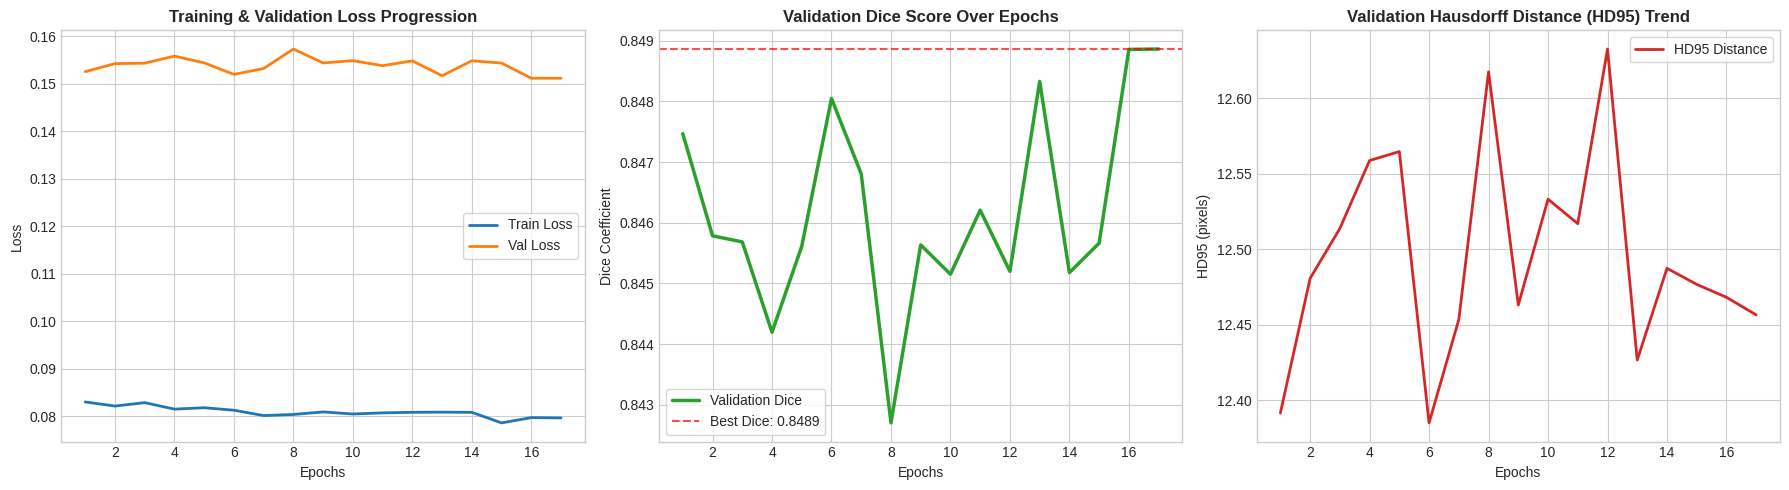

Evaluating Validation Split:   0%|          | 0/28 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════════════════
           DETAILED RECONSTRUCTION METRICS BY ACQUISITION ANGLE
════════════════════════════════════════════════════════════════════════
View Name                      | Mean Dice Score      | Mean HD95 (pixels)  
----------------------------------------------------------------------------
Right Lateral (RL) at -90°     | 0.7621               | 14.57               
Right Oblique (RO) at -45°     | 0.8706               | 11.90               
Frontal (F) at 0°              | 0.8851               | 10.82               
Left Oblique (LO) at +45°      | 0.8548               | 12.96               
Left Lateral (LL) at +90°      | 0.8110               | 12.03               
════════════════════════════════════════════════════════════════════════

 Generating side-by-side validation visual audits...


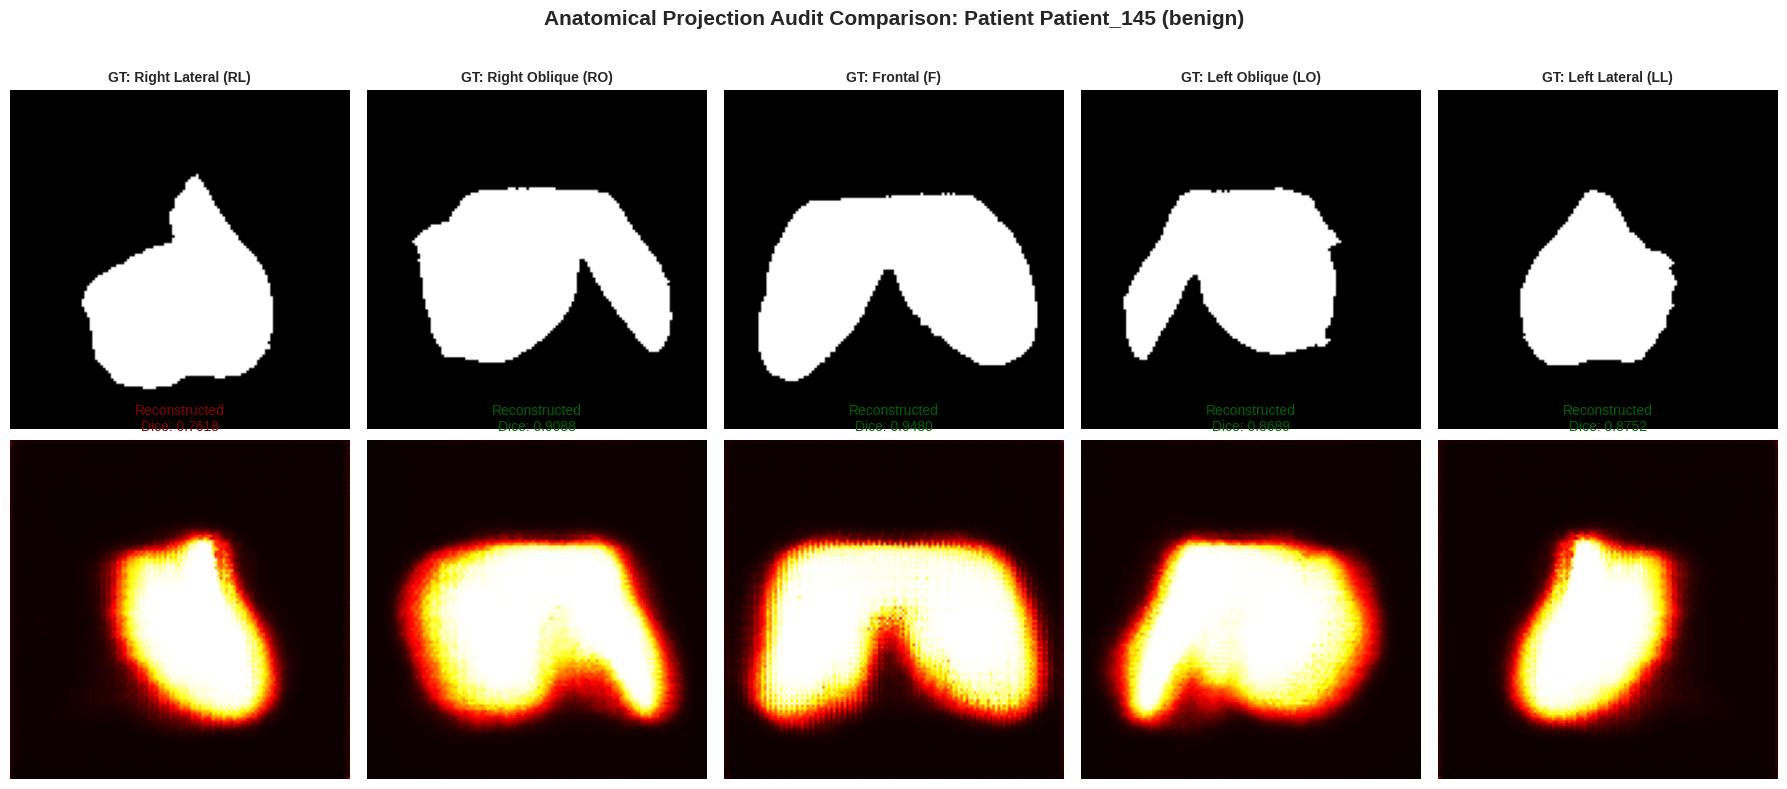

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# 3DBREASTNET — POST-FINE-TUNING EVALUATION & VISUAL DASHBOARD (DEFAULT GPU)
# ════════════════════════════════════════════════════════════════════════════

import os, sys, time, random
import numpy as np, cv2, matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch.utils.data import DataLoader

# 1. Config for Evaluation
EVAL_CFG = {
    "ckpt_dir":     "checkpoints_3d_finetuned",
    "best_ckpt":    r"checkpoints_3d_finetuned/3dbreastnet_finetuned_best.pth",
    "unet_ckpt":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth",
    "tiff_base":    r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient",
    "seed":         42,
}

def run_visual_diagnostics(cfg):
    # Target default active GPU automatically
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running diagnostics on device: {device}\n")

    # Load frozen segmentor
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(cfg["unet_ckpt"], map_location=device, weights_only=False))
    unet.eval()

    # Load validation data split deterministically
    groups = build_patient_groups(cfg["tiff_base"])
    rng = random.Random(cfg["seed"])
    ben = [g for g in groups if g.label.lower() == "benign"]
    mal = [g for g in groups if g.label.lower() != "benign"]
    rng.shuffle(ben); rng.shuffle(mal)
    s = 0.78
    val_groups = ben[int(len(ben)*s):] + mal[int(len(mal)*s):]
    
    val_dl = DataLoader(PatientDataset(val_groups, unet, device), batch_size=1, shuffle=False)

    # Initialize and load best fine-tuned weights
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    
    ckpt_path = Path(cfg["best_ckpt"])
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Fine-tuned checkpoint not found at {ckpt_path}!")
        
    print(f"Loading fine-tuned model checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()

    # ════════════════════════════════════════════════════════════════════════
    # PART 1: PLOT TRAINING HISTORY (Loss, Val Dice, Val HD95)
    # ════════════════════════════════════════════════════════════════════════
    if "hist" in ckpt:
        hist = ckpt["hist"]
        epochs = hist["epoch"]
        
        plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Dice-BCE Loss
        ax[0].plot(epochs, hist["train_loss"], label="Train Loss", color="#1f77b4", linewidth=2)
        ax[0].plot(epochs, hist["val_loss"], label="Val Loss", color="#ff7f0e", linewidth=2)
        ax[0].set_title("Training & Validation Loss Progression", fontsize=12, fontweight='bold')
        ax[0].set_xlabel("Epochs", fontsize=10)
        ax[0].set_ylabel("Loss", fontsize=10)
        ax[0].legend(frameon=True)
        
        # 2. Validation Dice
        ax[1].plot(epochs, hist["val_dice"], color="#2ca02c", linewidth=2.5, label="Validation Dice")
        ax[1].axhline(y=max(hist["val_dice"]), color="r", linestyle="--", alpha=0.7, 
                     label=f"Best Dice: {max(hist['val_dice']):.4f}")
        ax[1].set_title("Validation Dice Score Over Epochs", fontsize=12, fontweight='bold')
        ax[1].set_xlabel("Epochs", fontsize=10)
        ax[1].set_ylabel("Dice Coefficient", fontsize=10)
        ax[1].legend(frameon=True)
        
        # 3. Validation HD95
        ax[2].plot(epochs, hist["val_hd"], color="#d62728", linewidth=2, label="HD95 Distance")
        ax[2].set_title("Validation Hausdorff Distance (HD95) Trend", fontsize=12, fontweight='bold')
        ax[2].set_xlabel("Epochs", fontsize=10)
        ax[2].set_ylabel("HD95 (pixels)", fontsize=10)
        ax[2].legend(frameon=True)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Training history not found in checkpoint file.")

    # ════════════════════════════════════════════════════════════════════════
    # PART 2: COMPUTE DETAILED PER-VIEW PERFORMANCE METRICS
    # ════════════════════════════════════════════════════════════════════════
    val_angles = [-90., -45., 0., 45., 90.]
    view_names = [
        "Right Lateral (RL) at -90°", 
        "Right Oblique (RO) at -45°", 
        "Frontal (F) at 0°", 
        "Left Oblique (LO) at +45°", 
        "Left Lateral (LL) at +90°"
    ]
    
    # Track metrics for each angle individually
    angle_dices = {ang: [] for ang in val_angles}
    angle_hds = {ang: [] for ang in val_angles}
    
    with torch.no_grad():
        for batch in tqdm(val_dl, desc="Evaluating Validation Split"):
            m5 = batch["masks_5ch"].to(device)
            B = m5.size(0)
            
            vol = dec(enc(m5)).float()
            
            for i, ang in enumerate(val_angles):
                th = torch.full((B,), ang, device=device)
                proj = render_projection(vol, th)
                
                # Dice
                dl = dice_loss(proj, m5[:, i:i+1])
                dice_score = 1.0 - dl.item()
                angle_dices[ang].append(dice_score)
                
                # HD95
                pb = (proj > 0.5).cpu().numpy()
                mb = (m5[:, i:i+1] > 0.5).cpu().numpy()
                for b in range(B):
                    hd_score = hd95(pb[b,0], mb[b,0])
                    angle_hds[ang].append(hd_score)

    print("\n════════════════════════════════════════════════════════════════════════")
    print("           DETAILED RECONSTRUCTION METRICS BY ACQUISITION ANGLE")
    print("════════════════════════════════════════════════════════════════════════")
    print(f"{'View Name':<30} | {'Mean Dice Score':<20} | {'Mean HD95 (pixels)':<20}")
    print("-" * 76)
    for i, ang in enumerate(val_angles):
        mean_d = np.mean(angle_dices[ang])
        mean_h = np.mean(angle_hds[ang])
        print(f"{view_names[i]:<30} | {mean_d:<20.4f} | {mean_h:<20.2f}")
    print("════════════════════════════════════════════════════════════════════════\n")

    # ════════════════════════════════════════════════════════════════════════
    # PART 3: VISUAL SIDE-BY-SIDE PROJECTION AUDIT
    # ════════════════════════════════════════════════════════════════════════
    print(" Generating side-by-side validation visual audits...")
    sample_batch = next(iter(val_dl))
    m5_sample = sample_batch["masks_5ch"].to(device)
    pid_sample = sample_batch["patient_id"][0]
    label_sample = sample_batch["label"][0]
    
    with torch.no_grad():
        vol_sample = dec(enc(m5_sample)).float()
        
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    fig.suptitle(f"Anatomical Projection Audit Comparison: Patient {pid_sample} ({label_sample})", 
                 fontsize=15, fontweight='bold', y=0.98)
    
    for i, ang in enumerate(val_angles):
        # Ground Truth Mask
        gt_mask = m5_sample[0, i].cpu().numpy()
        axes[0, i].imshow(gt_mask, cmap='gray')
        axes[0, i].set_title(f"GT: {view_names[i].split(' at ')[0]}", fontsize=10, fontweight='bold')
        axes[0, i].axis('off')
        
        # Raymarched Predicted Projection
        th = torch.full((1,), ang, device=device)
        with torch.no_grad():
            proj_sample = render_projection(vol_sample, th).squeeze().cpu().numpy()
            
        axes[1, i].imshow(proj_sample, cmap='hot')
        
        # Calculate individual Dice score
        intersect = np.sum((proj_sample > 0.5) * (gt_mask > 0.5))
        denom = np.sum(proj_sample > 0.5) + np.sum(gt_mask > 0.5)
        ind_dice = (2.0 * intersect + 1e-6) / (denom + 1e-6)
        
        axes[1, i].set_title(f"Reconstructed\nDice: {ind_dice:.4f}", fontsize=10, color='darkgreen' if ind_dice > 0.8 else 'darkred')
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

# Run the diagnostics cell on default GPU
run_visual_diagnostics(EVAL_CFG)


## Post-Training 3D Visualization (Local Laptop)
Run this cell to perform inference using explicit local Windows paths.

In [ ]:
# ════════════════════════════════════════════════════════════════
# 3D VISUALIZATION OF RANDOM PATIENTS (SELF-CONTAINED)
# ════════════════════════════════════════════════════════════════
import random
import io
import numpy as np
import cv2
import tifffile
from IPython.display import display, Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from pathlib import Path
from dataclasses import dataclass
from typing import Dict
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import plotly.graph_objects as go

# ── 1. SELF-CONTAINED DATA UTILITIES ─────────────────────────────────────────
@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]

def get_view_key(filename):
    n = filename.lower()
    if "right later" in n: return "RL"
    if "right obli"  in n: return "RO"
    if "frontal" in n or "anterior" in n: return "F"
    if "left obliq"  in n: return "LO"
    if "left later"  in n: return "LL"
    return None

def build_patient_groups(tiff_base):
    tb = Path(tiff_base)
    pd_ = {}
    for tp in tb.rglob("*.tiff"):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {"views": {}}
        pd_[key]["views"][vk] = tp
    groups, skip = [], 0
    for (pid, lab), d in pd_.items():
        if len(d["views"]) == 5:
            groups.append(PatientGroup(pid, lab, d["views"]))
        else:
            skip += 1
    groups.sort(key=lambda g: g.patient_id)
    return groups

class PatientDataset(Dataset):
    def __init__(self, groups, unet, device, img_sz=256):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz = img_sz
        self.views = ["RL","RO","F","LO","LL"]
    def __len__(self): return len(self.groups)
    def __getitem__(self, idx):
        g = self.groups[idx]; thermals, masks = [], []
        for v in self.views:
            raw = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5).astype(np.float32)
            masks.append(cv2.resize(m, (128,128), interpolation=cv2.INTER_NEAREST))
        return {
            "masks_5ch": torch.tensor(np.stack(masks), dtype=torch.float32),
            "thermals_5ch": torch.tensor(np.stack(thermals), dtype=torch.float32),
            "patient_id": g.patient_id, "label": g.label,
        }

# ── 2. VISUALIZATION EXECUTION ───────────────────────────────────────────────
def visualize_random_patients_local(n=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Corrected Absolute Paths to match the Linux environment / Data directory
    unet_ckpt = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
    
    # Pointing to the NEW anatomically fine-tuned checkpoint
    ckpt_path = Path(r"checkpoints_3d_finetuned/3dbreastnet_finetuned_best.pth")
    
    if not ckpt_path.exists():
        print(f"Error: No trained model found at {ckpt_path}.")
        print("Make sure you have completed the fine-tuning cell first!")
        return
        
    print("Loading checkpoints...")
    
    # Initialize Models (Ensure their definitions are run beforehand)
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    print(f"Loading patient list from {tiff_base}...")
    groups = build_patient_groups(tiff_base)
    if len(groups) == 0: 
        print("No patients found. Check dataset path.")
        return
    
    selected = random.sample(groups, min(n, len(groups)))
    dataset = PatientDataset(selected, unet, device)
    
    print(f"Generating 3D models for {len(selected)} patients...")
    
    for i in range(len(dataset)):
        item = dataset[i]
        pid, label = item["patient_id"], item["label"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5))
            
        # Ensure we convert any mixed-precision output to float32 before NumPy/SciPy
        vol = vol.float()
        vol_np = vol[0, 0].cpu().numpy()
        
        # Apply a mild gaussian filter to smooth out any voxel staircasing before meshing
        vol_np = gaussian_filter(vol_np, sigma=1.0)
        
        try:
            verts, faces, normals, values = marching_cubes(vol_np, level=0.015) #marching cubes value can be adjusted for better mesh quality
            fig = go.Figure(data=[
                go.Mesh3d(
                    x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
                    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
                    colorscale='Hot',
                    intensity=verts[:, 2],
                    showscale=False
                )
            ])
            fig.update_layout(
                title=f"Patient: {pid} | Label: {label} (3D Reconstruction)",
                scene=dict(
                    xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
                    aspectmode='data'
                ),
                margin=dict(l=0, r=0, b=0, t=40)
            )
            fig.show()
        except ValueError:
            print(f"Could not generate 3D mesh for {pid} (volume might be empty).")

# Run it!
visualize_random_patients_local(n=5)


Using device: cuda
Loading checkpoints...
Loading patient list from /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient...
Generating 3D models for 5 patients...


## Export Geometry (.STL)
Run this cell to batch process **all available patients** through the network and export their 3D reconstructed geometries into universally readable `.stl` files. You can open these in Blender, MeshLab, or Windows 3D Viewer.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# 3DBREASTNET — BATCH STL MESH EXPORTER (SELF-CONTAINED)
# ════════════════════════════════════════════════════════════════════════════

import os, sys, time, struct
import numpy as np, cv2, tifffile
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from pathlib import Path
from dataclasses import dataclass
from typing import Dict
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

# ── 1. SELF-CONTAINED DATA UTILITIES ─────────────────────────────────────────
@dataclass
class PatientGroup:
    patient_id: str
    label: str
    views: Dict[str, Path]

def get_view_key(filename):
    n = filename.lower()
    if "right later" in n: return "RL"
    if "right obli"  in n: return "RO"
    if "frontal" in n or "anterior" in n: return "F"
    if "left obliq"  in n: return "LO"
    if "left later"  in n: return "LL"
    return None

def build_patient_groups(tiff_base):
    tb = Path(tiff_base)
    pd_ = {}
    for tp in tb.rglob("*.tiff"):
        parts = tp.relative_to(tb).parts
        if len(parts) < 3: continue
        pid, lab, fn = parts[0], parts[1], parts[-1]
        vk = get_view_key(fn)
        if not vk: continue
        key = (pid, lab)
        if key not in pd_: pd_[key] = {"views": {}}
        pd_[key]["views"][vk] = tp
    groups = []
    for (pid, lab), d in pd_.items():
        if len(d["views"]) == 5:
            groups.append(PatientGroup(pid, lab, d["views"]))
    groups.sort(key=lambda g: g.patient_id)
    return groups

class PatientDataset(Dataset):
    def __init__(self, groups, unet, device, img_sz=256):
        self.groups, self.unet, self.device = groups, unet, device
        self.img_sz = img_sz
        self.views = ["RL","RO","F","LO","LL"]
    def __len__(self): return len(self.groups)
    def __getitem__(self, idx):
        g = self.groups[idx]; thermals, masks = [], []
        for v in self.views:
            raw = tifffile.imread(str(g.views[v])).astype(np.float32)
            raw = cv2.resize(raw, (self.img_sz, self.img_sz))
            mn, mx = raw.min(), raw.max()
            norm = (raw - mn) / (mx - mn + 1e-8)
            thermals.append(norm)
            with torch.no_grad():
                inp = torch.tensor(norm).unsqueeze(0).unsqueeze(0).to(self.device)
                m = (torch.sigmoid(self.unet(inp)).squeeze().cpu().numpy() > 0.5).astype(np.float32)
            masks.append(cv2.resize(m, (128,128), interpolation=cv2.INTER_NEAREST))
        return {
            "masks_5ch": torch.tensor(np.stack(masks), dtype=torch.float32),
            "patient_id": g.patient_id, 
            "label": g.label,
        }

# ── 2. ZERO-DEPENDENCY BINARY STL EXPORTER ───────────────────────────────────
def save_stl_binary(filename, verts, faces):
    """Saves vertices and faces to a standard Binary STL file."""
    with open(filename, 'wb') as f:
        # 80 byte header
        f.write(b'\x00' * 80)
        # Number of triangles
        f.write(struct.pack('<I', len(faces)))
        
        for face in faces:
            v0, v1, v2 = verts[face[0]], verts[face[1]], verts[face[2]]
            
            # Normal calculation
            u = v1 - v0
            w = v2 - v0
            n = np.cross(u, w)
            n_norm = np.linalg.norm(n)
            if n_norm > 0: n = n / n_norm
            
            f.write(struct.pack('<3f', *n))     # Normal
            f.write(struct.pack('<3f', *v0))    # Vertex 1
            f.write(struct.pack('<3f', *v1))    # Vertex 2
            f.write(struct.pack('<3f', *v2))    # Vertex 3
            f.write(struct.pack('<H', 0))       # Attribute byte count

# ── 3. BATCH EXPORTER EXECUTION ──────────────────────────────────────────────
def export_all_patients_to_stl():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Batch Exporting on device: {device}\n")
    
    # ── PATH CONFIGURATIONS ──
    unet_ckpt = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
    
    # Pointed to the anatomically fine-tuned checkpoint!
    ckpt_path = Path(r"checkpoints_3d_finetuned/3dbreastnet_finetuned_best.pth")
    out_dir = Path(r"exported_stls_finetuned")
    out_dir.mkdir(parents=True, exist_ok=True)
    
    if not ckpt_path.exists():
        print(f"Error: Fine-tuned checkpoint not found at {ckpt_path}.")
        print("Please ensure your fine-tuning cell has finished running!")
        return

    print("Loading models and checkpoints...")
    
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()

    groups = build_patient_groups(tiff_base)
    if not groups:
        print("No patients found. Please check your tiff_base path.")
        return
        
    dataset = PatientDataset(groups, unet, device)
    
    print(f"\nStarting batch STL extraction for {len(dataset)} patients...")
    
    success_count = 0
    for i in tqdm(range(len(dataset)), desc="Exporting STLs"):
        item = dataset[i]
        pid, label = item["patient_id"], item["label"]
        
        # Clean up filename (prevent issues with slashes or spaces)
        clean_label = label.replace(" ", "_").replace("/", "-")
        filename = out_dir / f"{pid}_{clean_label}_reconstruction.stl"
        
        m5 = item["masks_5ch"].unsqueeze(0).to(device)
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5))
            
        vol = vol.float()
        vol_np = vol[0, 0].cpu().numpy()
        
        # Apply gentle structural smoothing
        vol_np = gaussian_filter(vol_np, sigma=1.0)
        
        try:
            # Extract mesh using Marching Cubes
            verts, faces, normals, values = marching_cubes(vol_np, level=0.5)
            
            # Save mesh using our standalone Binary STL writer
            save_stl_binary(filename, verts, faces)
            success_count += 1
            
        except ValueError:
            print(f"  [Warning] Could not generate 3D mesh for {pid}. Volume might be empty or threshold is too high.")
            
    print(f"\n✅ Success! {success_count}/{len(dataset)} anatomical meshes have been saved to the '{out_dir.absolute()}' directory.")

# Run the batch exporter
export_all_patients_to_stl()


Loading checkpoints...


NameError: name 'build_patient_groups' is not defined

## Test Single Patient STL Export
Run this cell to quickly generate and test the `.stl` output for a specific patient without batch processing the whole dataset.

In [ ]:
import struct
import torch
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes

# NOTE: All classes (UNet, Encoder2D, Decoder3D, PatientDataset, build_patient_groups)
# are defined in earlier cells. Make sure to run those cells first.

def save_stl(filename, verts, faces, normals):
    with open(filename, "wb") as f:
        f.write(b"\0" * 80)
        f.write(struct.pack("<I", len(faces)))
        for face in faces:
            f.write(struct.pack("<3f", 0.0, 0.0, 0.0))
            f.write(struct.pack("<3f", *verts[face[0]]))
            f.write(struct.pack("<3f", *verts[face[1]]))
            f.write(struct.pack("<3f", *verts[face[2]]))
            f.write(struct.pack("<H", 0))

def export_all_patients_to_stl():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    out_dir = Path("exported_stls")
    out_dir.mkdir(exist_ok=True)
    
    unet_ckpt = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/breast_segmentation_unet_best_gpu.pth"
    tiff_base = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
    ckpt_path = Path(r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/UNET_Segmentation/3DBreastnet/checkpoints_3d/3dbreastnet_best.pth")
    
    if not ckpt_path.exists():
        print(f"Error: Checkpoint not found at {ckpt_path}.")
        return
        
    print("Loading checkpoints...")
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    groups = build_patient_groups(tiff_base)
    if not groups:
        print("No complete patients found in the dataset.")
        return
        
    dataset = PatientDataset(groups, unet, device)
    print(f"Batch exporting {len(dataset)} patients to .STL...")
    
    for item in dataset:
        pid = item["patient_id"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            vol = dec(enc(m5)).float()
            
        vol_np = vol[0, 0].cpu().numpy()
        vol_np = np.pad(vol_np, pad_width=1, mode='constant', constant_values=0)
        vol_np = gaussian_filter(vol_np, sigma=2.0)
        
        try:
            verts, faces, normals, _ = marching_cubes(vol_np, level=0.5)
            verts = verts - 1.0
            verts = (verts / 63.5) - 1.0
            
            export_path = out_dir / f"{pid}_3d_geometry.stl"
            save_stl(export_path, verts, faces, normals)
            print(f"Exported {pid} -> {export_path}")
        except Exception as e:
            print(f"Skipping {pid} due to error: {e}")

    print(f"\nSuccess! All meshes have been saved to the '{out_dir.absolute()}' directory.")

# Run the batch exporter
export_all_patients_to_stl()

Loading checkpoints...
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_51 (benign): 4/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_193 (benign): 2/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26
Batch exporting 122 patients to .STL...
Exported Patient_1 -> exported_stls/Patient_1_3d_geometry.stl
Exported Patient_10 -> exported_stls/Patient_10_3d_geometry.stl
Exported Patient_100 -> exported_stls/Patient_100_3d_geometry.stl
Exported Patient_106 -> exported_stls/Patient_106_3d_geometry.stl
Exported Patient_107 -> exported

## Per Patient Projection Validation on Each View

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# Import model architectures and data loaders from your existing scripts
from models import UNet, Encoder2D, Decoder3D
from train import build_patient_groups, PatientDataset, dice_loss, render_projection

def evaluate_all_patients():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 1. Setup Directories
    out_dir = Path("projection_plots")
    out_dir.mkdir(exist_ok=True)
    
    # 2. Paths
    base_dir = Path("../..").resolve()
    unet_ckpt = base_dir / "UNET_Segmentation" / "breast_segmentation_unet_best_gpu.pth"
    tiff_base = base_dir / "data" / "organized_by_patient"
    ckpt_path = Path("checkpoints_3d/3dbreastnet_best.pth")
    
    # 3. Load Models
    print("Loading checkpoints...")
    unet = UNet().to(device)
    unet.load_state_dict(torch.load(unet_ckpt, map_location=device, weights_only=False))
    unet.eval()
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    enc = Encoder2D().to(device)
    dec = Decoder3D().to(device)
    enc.load_state_dict(ckpt["enc"])
    dec.load_state_dict(ckpt["dec"])
    enc.eval(); dec.eval()
    
    # 4. Load Data
    groups = build_patient_groups(tiff_base)
    if not groups:
        print("No patients found.")
        return
    dataset = PatientDataset(groups, unet, device)
    
    # 5. Evaluation Loop
    view_angles = [-90.0, -45.0, 0.0, 45.0, 90.0]
    view_names = ["Right Lateral (-90°)", "Right Oblique (-45°)", "Frontal (0°)", "Left Oblique (45°)", "Left Lateral (90°)"]
    
    all_dices = []
    
    print(f"\nEvaluating {len(dataset)} patients and generating 2x5 plots...")
    
    for item in tqdm(dataset):
        pid = item["patient_id"]
        m5 = item["masks_5ch"].unsqueeze(0).to(device)  # Ground Truth 2D Silhouettes [1, 5, 128, 128]
        
        with torch.no_grad(), torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            # Generate 3D Volume
            vol = dec(enc(m5)).float()
            
            patient_dices = []
            projections = []
            
            # Render and Calculate Dice for the 5 standard angles
            for i, angle in enumerate(view_angles):
                th = torch.tensor([angle], device=device, dtype=torch.float32)
                proj = render_projection(vol, th)  # [1, 1, 128, 128]
                
                gt_mask = m5[:, i:i+1] # [1, 1, 128, 128]
                dl = dice_loss(proj, gt_mask)
                d_score = 1.0 - dl.item()
                
                patient_dices.append(d_score)
                # Binarize the projection at 0.5 threshold to see the sharp silhouette curves
                binary_proj = (proj[0, 0] > 0.5).cpu().numpy().astype(np.float32)
                projections.append(binary_proj)
        
        all_dices.append(np.mean(patient_dices))
        
        # 6. Generate 2x5 Grid Plot
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        fig.suptitle(f"Patient: {pid} | Average Dice Score: {np.mean(patient_dices):.4f}", fontsize=16)
        
        for i in range(5):
            # Top Row: Ground Truth (U-Net mask)
            gt_img = m5[0, i].cpu().numpy()
            axes[0, i].imshow(gt_img, cmap='gray')
            axes[0, i].set_title(f"GT: {view_names[i]}")
            axes[0, i].axis('off')
            
            # Bottom Row: 3D Projected Silhouette
            axes[1, i].imshow(projections[i], cmap='gray')
            axes[1, i].set_title(f"Predicted Projection (Dice: {patient_dices[i]:.3f})")
            axes[1, i].axis('off')
            
        plt.tight_layout()
        plot_path = out_dir / f"{pid}_validation_grid.png"
        plt.savefig(plot_path, dpi=150)
        plt.close(fig)
        
    # 7. Final Results
    overall_mean = np.mean(all_dices)
    overall_std = np.std(all_dices)
    
    print("\n" + "="*50)
    print("FINAL VALIDATION RESULTS (Test on All Patients)")
    print("="*50)
    print(f"Total Patients Evaluated : {len(dataset)}")
    print(f"Overall Mean Dice Score  : {overall_mean:.4f}")
    print(f"Standard Deviation       : {overall_std:.4f}")
    print(f"Validation plots saved in: {out_dir.absolute()}")

if __name__ == "__main__":
    evaluate_all_patients()

Using device: cpu
Loading checkpoints...
  Skip Patient_104 (benign): 1/5 views
  Skip Patient_105 (benign): 1/5 views
  Skip Patient_109 (benign): 4/5 views
  Skip Patient_141 (benign): 4/5 views
  Skip Patient_160 (benign): 4/5 views
  Skip Patient_163 (benign): 4/5 views
  Skip Patient_18 (benign): 2/5 views
  Skip Patient_189 (benign): 2/5 views
  Skip Patient_193 (benign): 2/5 views
  Skip Patient_23 (benign): 3/5 views
  Skip Patient_243 (benign): 4/5 views
  Skip Patient_258 (malignant): 4/5 views
  Skip Patient_384 (malignant): 4/5 views
  Skip Patient_394 (malignant): 4/5 views
  Skip Patient_51 (benign): 4/5 views
Patients: 137 | Complete: 122 | Skipped: 15 | B=96 M=26

Evaluating 122 patients and generating 2x5 plots...


  0%|          | 0/122 [00:00<?, ?it/s]

KeyboardInterrupt: 